# Image Processing and Machine Vision

#### Assignment 02 - Fitting and Allignment

### Question 1 - Blob Detection

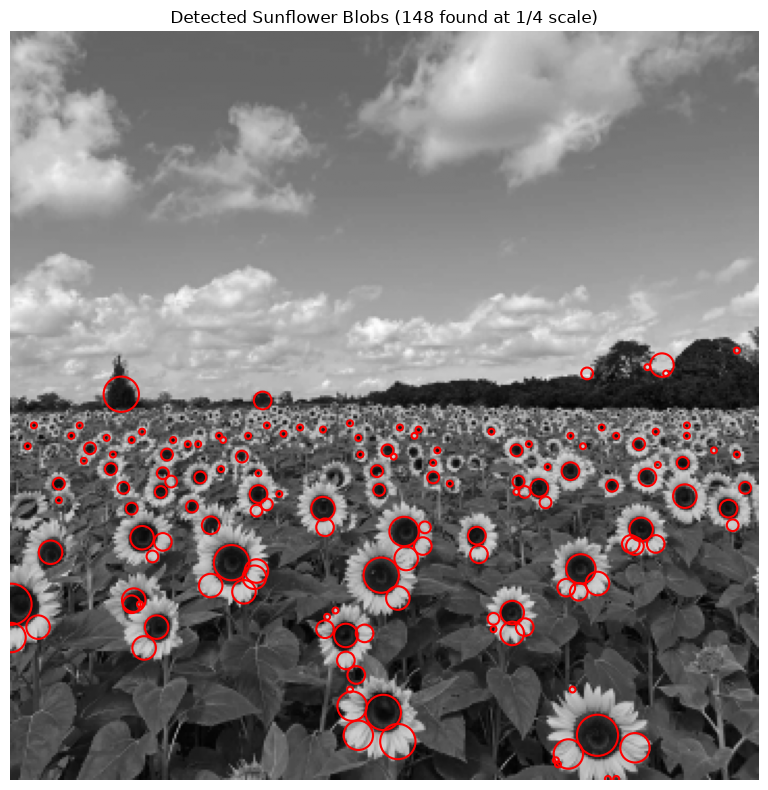

In [7]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

im =cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
im= cv.cvtColor(im, cv.COLOR_BGR2GRAY) #Converting to Gray Scale image

sigmas= np.linspace(1,10,10) #Sigma Values
h,w=im.shape #Height and Width of the image

im1= im.astype(np.float32)/255 #Scalinng the image 
scale_space = np.empty((h, w, len(sigmas)), dtype=np.float32)

for i, sigma in enumerate(sigmas):
    log_hw = int(np.ceil(3 * sigma))
    X, Y = np.meshgrid(np.arange(-log_hw, log_hw + 1), np.arange(-log_hw, log_hw + 1)) 
    # NLoG Filter
    r_sq = X**2 + Y**2
    LoG = (1.0 / (np.pi * sigma**2)) * ((r_sq / (2 * sigma**2)) - 1) * np.exp(-r_sq / (2 * sigma**2))
    scale_space[:, :, i] = np.abs(cv.filter2D(im1, -1, LoG))


threshold = 0.25  # We need to adjest the threshold 
local_max = maximum_filter(scale_space, size=(3, 3, 3)) == scale_space
detected_mask = local_max & (scale_space > threshold)

y_coords, x_coords, scale_indices = np.where(detected_mask)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(im,cmap='gray')

for y, x, s_idx in zip(y_coords, x_coords, scale_indices):
    sigma = sigmas[s_idx]
    radius = np.sqrt(2) * sigma
    circle = plt.Circle((x, y), radius, color='red', linewidth=1.5, fill=False)
    ax.add_patch(circle)

ax.set_axis_off()
plt.title(f'Detected Sunflower Blobs ({len(y_coords)} found at 1/4 scale)')
plt.tight_layout()
plt.show()

In [5]:
radii = np.sqrt(2) * sigmas[scale_indices]
max_idx = np.argmax(radii)
max_response = scale_space[max_y, max_x, scale_indices[max_idx]]
print(f"Largest blob: radius={radii[max_idx]:.2f}, sigma={sigmas[scale_indices[max_idx]]:.2f}, " 
      f"location=(x={x_coords[max_idx]},y={y_coords[max_idx]}), response={max_response:.4f}")


NameError: name 'max_y' is not defined

### Question 2 - RANSAC

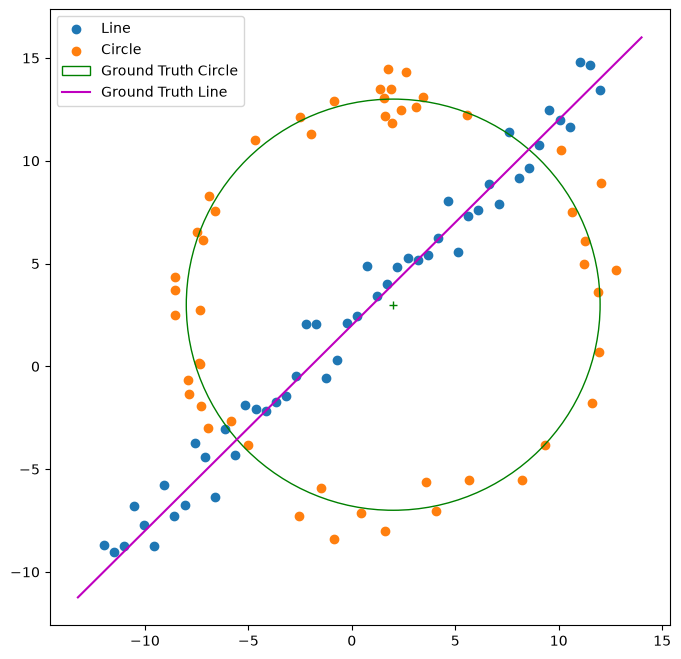

In [8]:
import numpy as np
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt

# np.random.seed(0)
N = 100
half_n = N // 2
r = 10
x0_gt, y0_gt = 2, 3  # Center
s = r / 16
t = np.random.uniform(0, 2 * np.pi, half_n)
n = s * np.random.randn(half_n)
x, y = x0_gt + (r + n) * np.cos(t), y0_gt + (r + n) * np.sin(t)
X_circ = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))
s = 1.0
m, b = 1, 2
x = np.linspace(-12, 12, half_n)
y = m * x + b + s * np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))
X = np.vstack((X_circ, X_line))  # All points
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(X_line[:, 0], X_line[:, 1], label="Line")
ax.scatter(X_circ[:, 0], X_circ[:, 1], label="Circle")
circle_gt = plt.Circle(
    (x0_gt, y0_gt), r, color="g", fill=False, label="Ground Truth Circle"
)
ax.add_patch(circle_gt)
ax.plot((x0_gt), (y0_gt), "+", color="g")
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m * x_ + b
plt.plot(x_, y_, color="m", label="Ground Truth Line")
plt.legend()
plt.show()